##Installing libraries

In [ ]:
!pip install keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 1.1 MB/s eta 0:00:00


##Impoting all libraries

In [26]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import re
from wordcloud import WordCloud, STOPWORDS
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Bidirectional, LSTM, Conv1D, MaxPooling1D, Flatten, Dense, Dropout, Embedding
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
import keras_tuner as kt
from tensorflow.keras.optimizers import Adam
import pickle
import json

##Loading Dataset

In [ ]:
df = pd.read_csv("/content/IMDB Dataset.csv")
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


##Explore Dataset

--- Dataset Exploration ---

Dataset Shape: (50000, 2)

Null Values:
 review       0
sentiment    0
dtype: int64

Number of Duplicate Reviews (before dropping): 418
Duplicates dropped. New Dataset Shape: (49582, 2)

Sentiment Distribution:
 sentiment
positive    24884
negative    24698
Name: count, dtype: int64


/tmp/ipykernel_5506/2480308707.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='sentiment', palette='viridis')


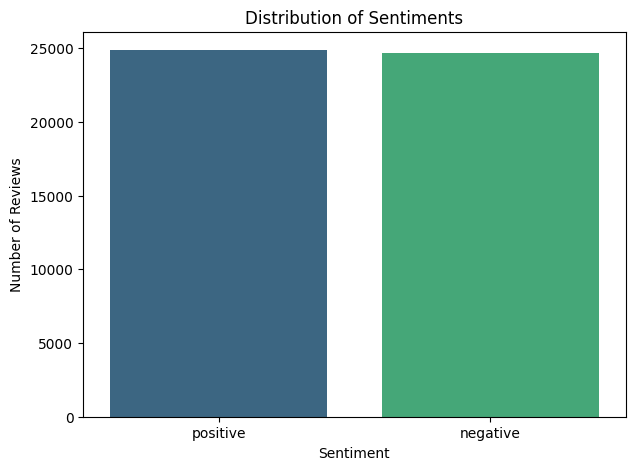


Review Lengths Description:
 count    49582.000000
mean      1310.568230
std        990.762238
min         32.000000
25%        699.000000
50%        971.000000
75%       1592.000000
max      13704.000000
Name: review_length, dtype: float64


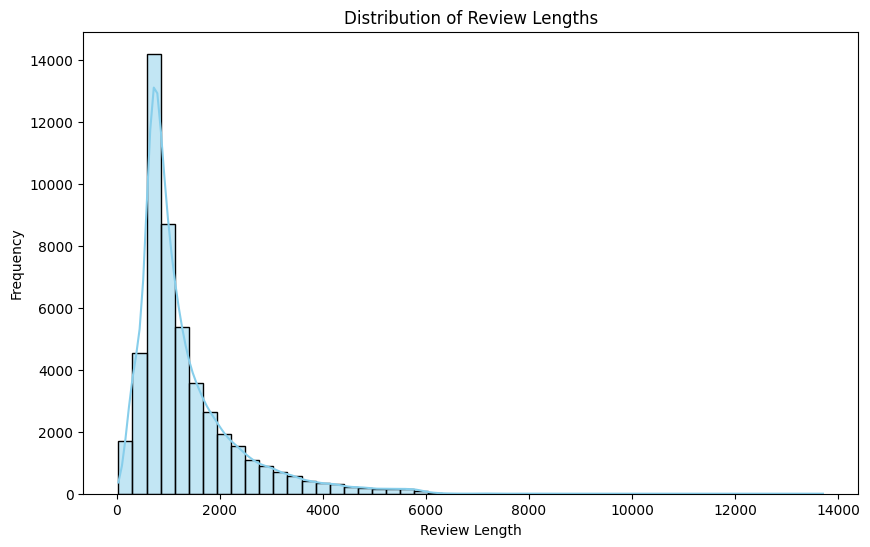


Generating Word Clouds...


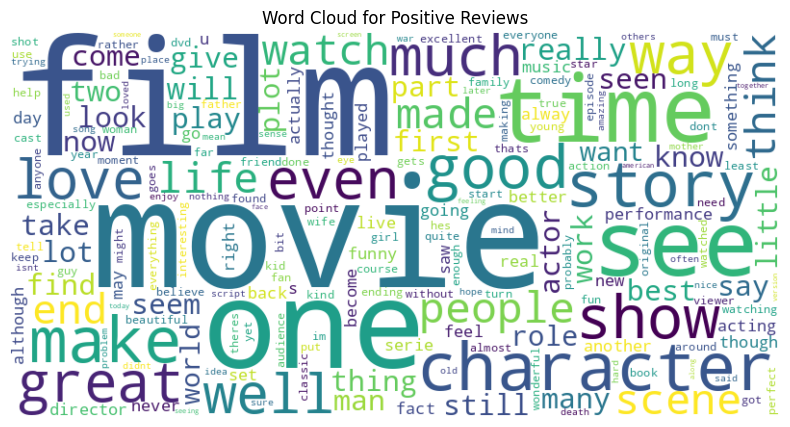

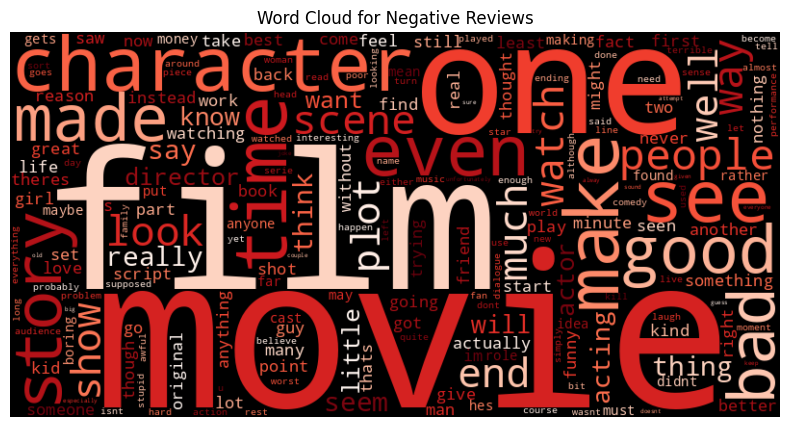

--- Exploration Complete ---


In [ ]:
print("--- Dataset Exploration ---")

# 1. Check Shape
print("\nDataset Shape:", df.shape)

# 2. Check Null Values
print("\nNull Values:\n", df.isnull().sum())

# 3. Check Duplicate Reviews
duplicates_before = df.duplicated().sum()
print("\nNumber of Duplicate Reviews (before dropping):", duplicates_before)
if duplicates_before > 0:
    df.drop_duplicates(inplace=True)
    print("Duplicates dropped. New Dataset Shape:", df.shape)

# 4. Sentiment Distribution
sentiment_counts = df['sentiment'].value_counts()
print("\nSentiment Distribution:\n", sentiment_counts)

# Visualize Sentiment Distribution
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='sentiment', palette='viridis')
plt.title('Distribution of Sentiments')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.show()

# 5. Review Lengths
df['review_length'] = df['review'].apply(len)
print("\nReview Lengths Description:\n", df['review_length'].describe())

# Visualize Review Lengths Distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['review_length'], bins=50, kde=True, color='skyblue')
plt.title('Distribution of Review Lengths')
plt.xlabel('Review Length')
plt.ylabel('Frequency')
plt.show()

# Preprocess text for word clouds (remove HTML tags and punctuation)
def preprocess_text_for_wordcloud(text):
    text = re.sub(r'<br />', ' ', text)  # Remove <br /> tags
    text = re.sub(r'[^a-zA-Z\s]', '', text) # Remove punctuation
    text = text.lower()
    return text

df['cleaned_review'] = df['review'].apply(preprocess_text_for_wordcloud)

# Separate reviews by sentiment
positive_reviews_text = ' '.join(df[df['sentiment'] == 'positive']['cleaned_review'])
negative_reviews_text = ' '.join(df[df['sentiment'] == 'negative']['cleaned_review'])

# 6. Generate Word Clouds
print("\nGenerating Word Clouds...")

# Word Cloud for Positive Reviews
wordcloud_positive = WordCloud(width=800, height=400, background_color='white', stopwords=STOPWORDS).generate(positive_reviews_text)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_positive, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud for Positive Reviews')
plt.show()

# Word Cloud for Negative Reviews
wordcloud_negative = WordCloud(width=800, height=400, background_color='black', stopwords=STOPWORDS, colormap='Reds').generate(negative_reviews_text)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_negative, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud for Negative Reviews')
plt.show()

print("--- Exploration Complete ---")

##Data Cleaning

In [ ]:
# Download necessary NLTK data (run once)
# NLTK's download function only downloads if not already present
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('punkt_tab') # Added download for punkt_tab


stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text_pipeline(text):
    # 1. Lowercasing
    text = text.lower()

    # 2. Remove HTML tags
    text = re.sub(r'<.*?>', ' ', text)

    # 3. Remove punctuation and special characters
    # Keeps only alphabetic characters and spaces
    text = re.sub(r'[^a-z\s]', '', text)

    # Tokenization
    tokens = word_tokenize(text)

    # 4. Remove stopwords and 5. Lemmatization
    cleaned_tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]

    # Join tokens back into a string
    return ' '.join(cleaned_tokens)

print("Applying text cleaning pipeline...")
# Apply the cleaning function to the 'review' column
df['cleaned_review_processed'] = df['review'].apply(clean_text_pipeline)

print("Text cleaning complete. Displaying first 5 cleaned reviews:")
for i, review in enumerate(df['cleaned_review_processed'].head()):
    print(f"Review {i+1}: {review}")


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Applying text cleaning pipeline...
Text cleaning complete. Displaying first 5 cleaned reviews:
Review 1: one reviewer mentioned watching oz episode youll hooked right exactly happened first thing struck oz brutality unflinching scene violence set right word go trust show faint hearted timid show pull punch regard drug sex violence hardcore classic use word called oz nickname given oswald maximum security state penitentary focus mainly emerald city experimental section prison cell glass front face inwards privacy high agenda em city home manyaryans muslim gangsta latino christian italian irish moreso scuffle death stare dodgy dealing shady agreement never far away would say main appeal show due fact go show wouldnt dare forget pretty picture painted mainstream audience forget charm forget romanceoz doesnt mess around first episode ever saw struck nasty surreal couldnt say ready watched developed taste oz got accustomed high level graphic violence violence injustice crooked guard wholl s

##NLP Processing

In [ ]:
print("--- NLP Processing: Tokenization with Keras Tokenizer ---")

# Define parameters for tokenization
VOCAB_SIZE = 10000  # You can adjust this based on your dataset and needs
OOV_TOKEN = '<OOV>' # Out-of-vocabulary token
MAX_SEQUENCE_LENGTH = 120 # Max length of sequences, can be adjusted

# 1. Vocabulary creation
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token=OOV_TOKEN)
tokenizer.fit_on_texts(df['cleaned_review_processed'])

print(f"\nVocabulary size (top {VOCAB_SIZE} words): {len(tokenizer.word_index)}")
print("Top 10 words in vocabulary:", list(tokenizer.word_index.keys())[:10])

# 2. Convert text → sequences
text_sequences = tokenizer.texts_to_sequences(df['cleaned_review_processed'])

print(f"\nFirst 5 original cleaned reviews (first 50 chars):\n")
for i, review in enumerate(df['cleaned_review_processed'].head()):
    print(f"Review {i+1}: {review[:50]}...")
print(f"\nFirst 5 sequences (first 10 tokens):\n")
for i, seq in enumerate(text_sequences[:5]):
    print(f"Sequence {i+1}: {seq[:10]}...")

# 3. Padding sequences
padded_sequences = pad_sequences(text_sequences, maxlen=MAX_SEQUENCE_LENGTH, padding='post', truncating='post')

print(f"\nShape of padded sequences: {padded_sequences.shape}")
print(f"Example of a padded sequence (first review, first {MAX_SEQUENCE_LENGTH} tokens):\n{padded_sequences[0]}")

print("--- Tokenization Complete ---")


--- NLP Processing: Tokenization with Keras Tokenizer ---

Vocabulary size (top 10000 words): 151054
Top 10 words in vocabulary: ['<OOV>', 'movie', 'film', 'one', 'like', 'time', 'good', 'character', 'story', 'even']

First 5 original cleaned reviews (first 50 chars):

Review 1: one reviewer mentioned watching oz episode youll h...
Review 2: wonderful little production filming technique unas...
Review 3: thought wonderful way spend time hot summer weeken...
Review 4: basically there family little boy jake think there...
Review 5: petter matteis love time money visually stunning f...

First 5 sequences (first 10 tokens):

Sequence 1: [4, 1030, 937, 66, 3008, 173, 371, 2885, 105, 503]...
Sequence 2: [293, 48, 235, 1204, 1555, 1, 1, 1312, 60, 1]...
Sequence 3: [97, 293, 26, 1001, 6, 786, 1269, 2180, 1073, 794]...
Sequence 4: [558, 128, 122, 48, 205, 3270, 29, 128, 514, 3556]...
Sequence 5: [1, 1, 35, 6, 197, 1902, 1237, 3, 34, 280]...

Shape of padded sequences: (49582, 120)
Example of a 

##Train-Test Split

In [ ]:
print("--- Data Preparation: Train-Test Split ---")

# Convert sentiment labels to numerical format (0 for negative, 1 for positive)
# Assuming 'df' DataFrame and 'sentiment' column are available
# The 'sentiment' column should have 'positive' and 'negative' values
sentiment_labels = df['sentiment'].apply(lambda x: 1 if x == 'positive' else 0)

# Features (X) are the padded sequences, Labels (y) are the numerical sentiment labels
X = padded_sequences
y = np.array(sentiment_labels)

# Perform 80/20 train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nShape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

print("--- Train-Test Split Complete ---")

--- Data Preparation: Train-Test Split ---

Shape of X_train: (39665, 120)
Shape of X_test: (9917, 120)
Shape of y_train: (39665,)
Shape of y_test: (9917,)
--- Train-Test Split Complete ---


##Building CNN Model

In [ ]:
print("--- Building CNN Model Architecture ---")

# Model parameters
EMBEDDING_DIM = 128  # Dimension of the word embeddings
FILTERS = 128        # Number of filters for the Conv1D layer
KERNEL_SIZE = 5      # Kernel size for the Conv1D layer

# Build the Sequential Model
model = Sequential([
    # Embedding layer: Converts word indices into dense vectors
    # input_dim is VOCAB_SIZE + 1 because tokenizer.word_index starts from 1
    Embedding(input_dim=VOCAB_SIZE + 1, output_dim=EMBEDDING_DIM),

    # Convolutional Layer: Learns local features from the embeddings
    Conv1D(filters=FILTERS, kernel_size=KERNEL_SIZE, activation='relu'),

    # Max Pooling Layer: Reduces dimensionality and extracts dominant features
    MaxPooling1D(pool_size=2),

    # Flatten Layer: Converts the 2D feature maps into a 1D vector for dense layers
    Flatten(),

    # Dense Layer 1: Fully connected layer for further feature processing
    Dense(128, activation='relu'),
    Dropout(0.5), # Dropout for regularization to prevent overfitting

    # Output Layer: Single neuron with sigmoid activation for binary classification
    Dense(1, activation='sigmoid')
])

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Display model summary
print("CNN Model Summary:")
model.summary()

print("--- CNN Model Architecture Built ---")

--- Building CNN Model Architecture ---
CNN Model Summary:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

--- CNN Model Architecture Built ---


##CNN Model Training

In [ ]:
print("--- CNN Model Training ---")

# Define Callbacks
# EarlyStopping: Monitor 'val_loss' and stop training if it doesn't improve for 5 epochs
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# ReduceLROnPlateau: Reduce learning rate if 'val_loss' doesn't improve for 3 epochs
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=0.00001, verbose=1)

# Train the model
# Using a validation split to monitor performance on unseen data during training
history = model.fit(
    X_train,
    y_train,
    epochs=20, # Number of epochs, EarlyStopping will stop it earlier if no improvement
    batch_size=32,
    validation_split=0.1, # 10% of the training data will be used for validation
    callbacks=[early_stopping, reduce_lr]
)

print("--- CNN Model Training Complete ---")

--- CNN Model Training ---
Epoch 1/20
1116/1116 ━━━━━━━━━━━━━━━━━━━━ 94s 82ms/step - accuracy: 0.8264 - loss: 0.3775 - val_accuracy: 0.8697 - val_loss: 0.3088 - learning_rate: 0.0010
Epoch 2/20
1116/1116 ━━━━━━━━━━━━━━━━━━━━ 160s 98ms/step - accuracy: 0.9108 - loss: 0.2274 - val_accuracy: 0.8747 - val_loss: 0.3004 - learning_rate: 0.0010
Epoch 3/20
1116/1116 ━━━━━━━━━━━━━━━━━━━━ 97s 87ms/step - accuracy: 0.9513 - loss: 0.1294 - val_accuracy: 0.8634 - val_loss: 0.4145 - learning_rate: 0.0010
Epoch 4/20
1116/1116 ━━━━━━━━━━━━━━━━━━━━ 95s 85ms/step - accuracy: 0.9813 - loss: 0.0545 - val_accuracy: 0.8631 - val_loss: 0.5747 - learning_rate: 0.0010
Epoch 5/20
1116/1116 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.9923 - loss: 0.0252
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
1116/1116 ━━━━━━━━━━━━━━━━━━━━ 92s 83ms/step - accuracy: 0.9904 - loss: 0.0296 - val_accuracy: 0.8591 - val_loss: 0.7826 - learning_rate: 0.0010
Epoch 6/20
1116/1116 ━━━━━━━━━━━━━━━━━

##CNN Model Evaluation

--- CNN Model Evaluation ---
310/310 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step

Accuracy: 0.8724
Precision: 0.8684
Recall: 0.8790
F1-score: 0.8737
ROC-AUC: 0.9466

Confusion Matrix:


<Figure size 800x600 with 0 Axes>

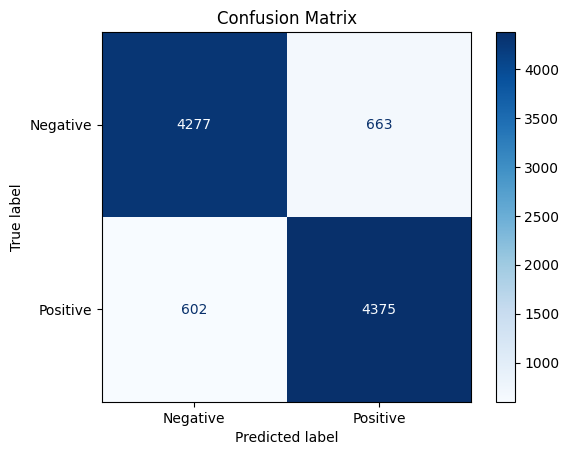


ROC Curve:


<Figure size 800x600 with 0 Axes>

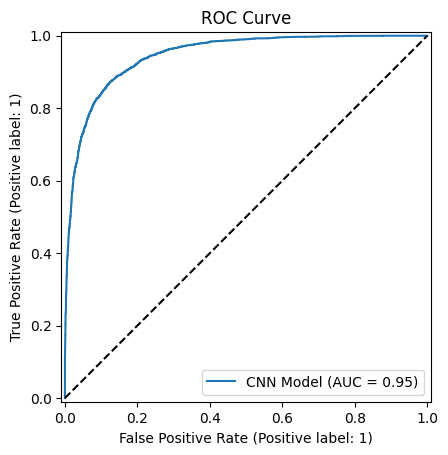


Visualizing Training History:


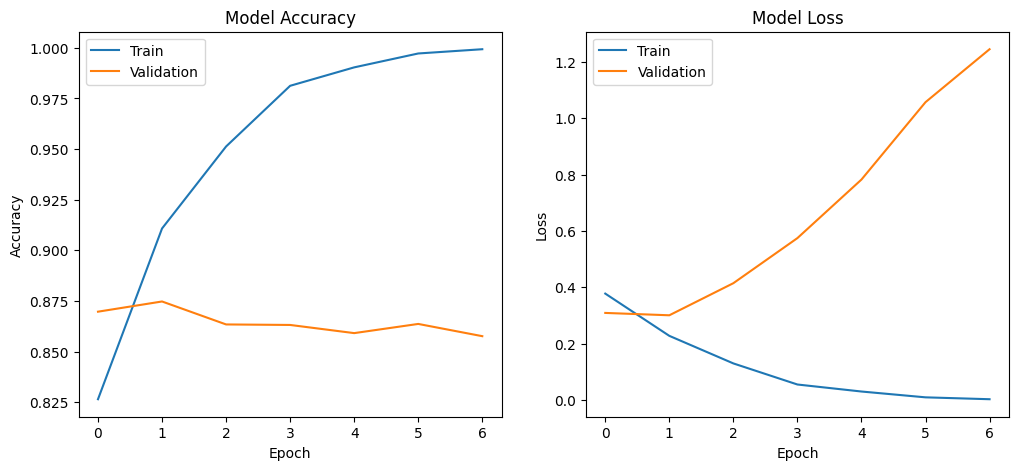

--- CNN Model Evaluation Complete ---


In [ ]:
print("--- CNN Model Evaluation ---")

# 1. Predict on test data
# model.predict returns probabilities for the positive class
y_pred_prob = model.predict(X_test)

# Convert probabilities to binary predictions (0 or 1)
y_pred = (y_pred_prob > 0.5).astype(int)

# 2. Evaluate Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_prob)

print(f"\nAccuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")

# 3. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")

plt.figure(figsize=(8, 6))
cmd = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negative', 'Positive'])
cmd.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

# 4. ROC Curve
print("\nROC Curve:")
plt.figure(figsize=(8, 6))
RocCurveDisplay.from_predictions(y_test, y_pred_prob, name='CNN Model')
plt.plot([0, 1], [0, 1], 'k--') # Diagonal dashed line
plt.title('ROC Curve')
plt.show()

# 5. Visualize Training History (Accuracy and Loss curves)
print("\nVisualizing Training History:")

history_dict = history.history

# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_dict['accuracy'])
plt.plot(history_dict['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history_dict['loss'])
plt.plot(history_dict['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

print("--- CNN Model Evaluation Complete ---")

##Building LSTM Model

In [ ]:
print("-- Building LSTM Model Architecture ---")

# Model parameters (reusing EMBEDDING_DIM from CNN for consistency)
EMBEDDING_DIM = 128  # Dimension of the word embeddings
LSTM_UNITS = 128     # Number of LSTM units

# Build the Sequential Model
model_lstm = Sequential([
    # Embedding layer: Converts word indices into dense vectors
    Embedding(input_dim=VOCAB_SIZE + 1, output_dim=EMBEDDING_DIM),

    # LSTM Layer: Processes sequences to capture long-term dependencies
    LSTM(LSTM_UNITS),

    # Dropout Layer: Regularization to prevent overfitting
    Dropout(0.5),

    # Dense Layer: Fully connected layer for classification
    Dense(64, activation='relu'),
    Dropout(0.5),

    # Output Layer: Single neuron with sigmoid activation for binary classification
    Dense(1, activation='sigmoid')
])

# Compile the model
model_lstm.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Display model summary
print("LSTM Model Summary:")
model_lstm.summary()

print("--- LSTM Model Architecture Built ---")

-- Building LSTM Model Architecture ---
LSTM Model Summary:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

--- LSTM Model Architecture Built ---


##LSTM Model

In [ ]:
print("--- LSTM Model Training ---")

# Define Callbacks
# EarlyStopping: Monitor 'val_loss' and stop training if it doesn't improve for 5 epochs
early_stopping_lstm = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# ReduceLROnPlateau: Reduce learning rate if 'val_loss' doesn't improve for 3 epochs
reduce_lr_lstm = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=0.00001, verbose=1)

# Train the LSTM model
# Using a validation split to monitor performance on unseen data during training
history_lstm = model_lstm.fit(
    X_train,
    y_train,
    epochs=20, # Number of epochs, EarlyStopping will stop it earlier if no improvement
    batch_size=32,
    validation_split=0.1, # 10% of the training data will be used for validation
    callbacks=[early_stopping_lstm, reduce_lr_lstm]
)

print("--- LSTM Model Training Complete ---")

--- LSTM Model Training ---
Epoch 1/20
1116/1116 ━━━━━━━━━━━━━━━━━━━━ 250s 221ms/step - accuracy: 0.5293 - loss: 0.6874 - val_accuracy: 0.5069 - val_loss: 0.6918 - learning_rate: 0.0010
Epoch 2/20
1116/1116 ━━━━━━━━━━━━━━━━━━━━ 251s 225ms/step - accuracy: 0.5373 - loss: 0.6854 - val_accuracy: 0.6622 - val_loss: 0.6354 - learning_rate: 0.0010
Epoch 3/20
1116/1116 ━━━━━━━━━━━━━━━━━━━━ 251s 225ms/step - accuracy: 0.7782 - loss: 0.4814 - val_accuracy: 0.8649 - val_loss: 0.3325 - learning_rate: 0.0010
Epoch 4/20
1116/1116 ━━━━━━━━━━━━━━━━━━━━ 250s 224ms/step - accuracy: 0.8935 - loss: 0.2850 - val_accuracy: 0.8793 - val_loss: 0.3158 - learning_rate: 0.0010
Epoch 5/20
1116/1116 ━━━━━━━━━━━━━━━━━━━━ 251s 225ms/step - accuracy: 0.9228 - loss: 0.2112 - val_accuracy: 0.8795 - val_loss: 0.3246 - learning_rate: 0.0010
Epoch 6/20
1116/1116 ━━━━━━━━━━━━━━━━━━━━ 252s 226ms/step - accuracy: 0.9514 - loss: 0.1479 - val_accuracy: 0.8669 - val_loss: 0.3922 - learning_rate: 0.0010
Epoch 7/20
1116/1116 ━━━

##LSTM Model Evaluation

--- LSTM Model Evaluation ---
310/310 ━━━━━━━━━━━━━━━━━━━━ 21s 68ms/step

LSTM Accuracy: 0.8711
LSTM Precision: 0.8646
LSTM Recall: 0.8813
LSTM F1-score: 0.8728
LSTM ROC-AUC: 0.9443

LSTM Confusion Matrix:


<Figure size 800x600 with 0 Axes>

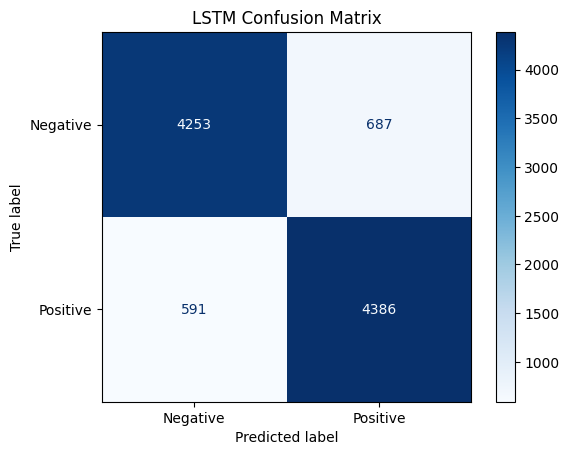


LSTM ROC Curve:


<Figure size 800x600 with 0 Axes>

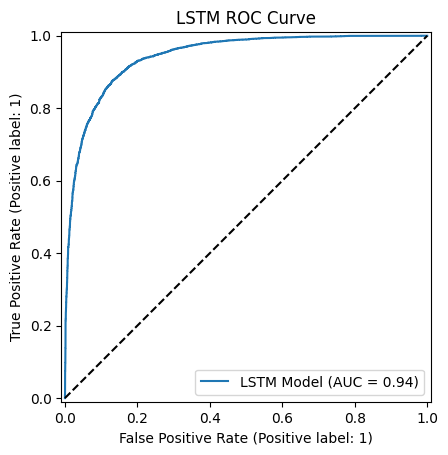


Visualizing LSTM Training History:


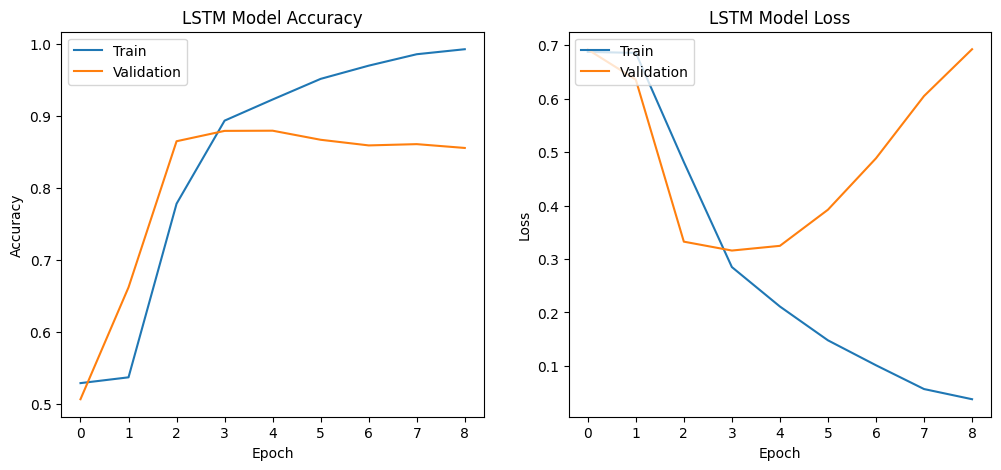

--- LSTM Model Evaluation Complete ---

--- Model Comparison ---

Model Comparison Table:
| Model   |   Accuracy |   Precision |   Recall |   F1-score |   ROC-AUC |   Training Epochs |
|:--------|-----------:|------------:|---------:|-----------:|----------:|------------------:|
| CNN     |     0.8724 |      0.8684 |   0.879  |     0.8737 |    0.9466 |                 7 |
| LSTM    |     0.8711 |      0.8646 |   0.8813 |     0.8728 |    0.9443 |                 9 |


/tmp/ipykernel_5506/255238010.py:88: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Accuracy', data=comparison_df, palette='deep')
/tmp/ipykernel_5506/255238010.py:94: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='F1-score', data=comparison_df, palette='deep')


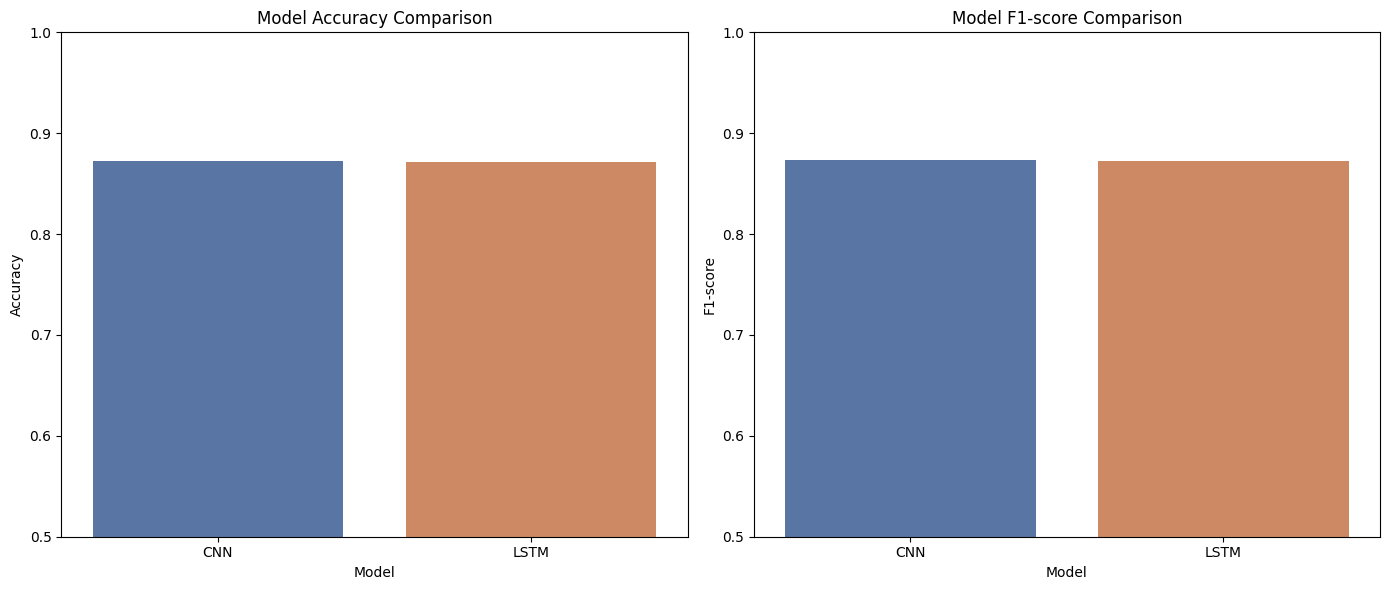

--- Model Comparison Complete ---


In [ ]:
print("--- LSTM Model Evaluation ---")

# 1. Predict on test data for LSTM
y_pred_prob_lstm = model_lstm.predict(X_test)
y_pred_lstm = (y_pred_prob_lstm > 0.5).astype(int)

# 2. Evaluate LSTM Metrics
accuracy_lstm = accuracy_score(y_test, y_pred_lstm)
precision_lstm = precision_score(y_test, y_pred_lstm)
recall_lstm = recall_score(y_test, y_pred_lstm)
f1_lstm = f1_score(y_test, y_pred_lstm)
roc_auc_lstm = roc_auc_score(y_test, y_pred_prob_lstm)

print(f"\nLSTM Accuracy: {accuracy_lstm:.4f}")
print(f"LSTM Precision: {precision_lstm:.4f}")
print(f"LSTM Recall: {recall_lstm:.4f}")
print(f"LSTM F1-score: {f1_lstm:.4f}")
print(f"LSTM ROC-AUC: {roc_auc_lstm:.4f}")

# 3. Confusion Matrix for LSTM
cm_lstm = confusion_matrix(y_test, y_pred_lstm)
print("\nLSTM Confusion Matrix:")
plt.figure(figsize=(8, 6))
cmd_lstm = ConfusionMatrixDisplay(confusion_matrix=cm_lstm, display_labels=['Negative', 'Positive'])
cmd_lstm.plot(cmap=plt.cm.Blues)
plt.title('LSTM Confusion Matrix')
plt.show()

# 4. ROC Curve for LSTM
print("\nLSTM ROC Curve:")
plt.figure(figsize=(8, 6))
RocCurveDisplay.from_predictions(y_test, y_pred_prob_lstm, name='LSTM Model')
plt.plot([0, 1], [0, 1], 'k--') # Diagonal dashed line
plt.title('LSTM ROC Curve')
plt.show()

# 5. Visualize LSTM Training History
print("\nVisualizing LSTM Training History:")
history_dict_lstm = history_lstm.history

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_dict_lstm['accuracy'])
plt.plot(history_dict_lstm['val_accuracy'])
plt.title('LSTM Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.subplot(1, 2, 2)
plt.plot(history_dict_lstm['loss'])
plt.plot(history_dict_lstm['val_loss'])
plt.title('LSTM Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

print("--- LSTM Model Evaluation Complete ---")

print("\n--- Model Comparison ---")

# CNN metrics (from previous execution, assuming they are available in the environment)
# accuracy, precision, recall, f1, roc_auc
# history_dict (for CNN training epochs)

# Gather metrics for comparison
metrics_data = {
    'Model': ['CNN', 'LSTM'],
    'Accuracy': [accuracy, accuracy_lstm],
    'Precision': [precision, precision_lstm],
    'Recall': [recall, recall_lstm],
    'F1-score': [f1, f1_lstm],
    'ROC-AUC': [roc_auc, roc_auc_lstm],
    'Training Epochs': [len(history_dict['accuracy']), len(history_dict_lstm['accuracy'])]
}

# Create DataFrame for comparison table
comparison_df = pd.DataFrame(metrics_data)
print("\nModel Comparison Table:")
print(comparison_df.round(4).to_markdown(index=False))

# Visualization Charts for Comparison
plt.figure(figsize=(14, 6))

# Bar chart for Accuracy
plt.subplot(1, 2, 1)
sns.barplot(x='Model', y='Accuracy', data=comparison_df, palette='deep')
plt.title('Model Accuracy Comparison')
plt.ylim(0.5, 1.0) # Set y-limit for better comparison

# Bar chart for F1-score
plt.subplot(1, 2, 2)
sns.barplot(x='Model', y='F1-score', data=comparison_df, palette='deep')
plt.title('Model F1-score Comparison')
plt.ylim(0.5, 1.0)

plt.tight_layout()
plt.show()

print("--- Model Comparison Complete ---")


##BiLSTM Model and CNN+LSTM

--- BiLSTM Model Architecture ---
BiLSTM Model Summary:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

--- BiLSTM Model Training ---
Epoch 1/20
1116/1116 ━━━━━━━━━━━━━━━━━━━━ 470s 417ms/step - accuracy: 0.8018 - loss: 0.4280 - val_accuracy: 0.8752 - val_loss: 0.3086 - learning_rate: 0.0010
Epoch 2/20
1116/1116 ━━━━━━━━━━━━━━━━━━━━ 463s 415ms/step - accuracy: 0.8965 - loss: 0.2692 - val_accuracy: 0.8795 - val_loss: 0.3035 - learning_rate: 0.0010
Epoch 3/20
1116/1116 ━━━━━━━━━━━━━━━━━━━━ 448s 402ms/step - accuracy: 0.9278 - loss: 0.1969 - val_accuracy: 0.8697 - val_loss: 0.3964 - learning_rate: 0.0010
Epoch 4/20
1116/1116 ━━━━━━━━━━━━━━━━━━━━ 512s 410ms/step - accuracy: 0.9526 - loss: 0.1319 - val_accuracy: 0.8616 - val_loss: 0.4112 - learning_rate: 0.0010
Epoch 5/20
1116/1116 ━━━━━━━━━━━━━━━━━━━━ 0s 404ms/step - accuracy: 0.9751 - loss: 0.0763
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
1116/1116 ━━━━━━━━━━━━━━━━━━━━ 472s 423ms/step - accuracy: 0.9709 - loss: 0.0865 - val_accuracy: 0.8682 - val_loss: 0.4880 - learning_rate: 0.0010
Epoch 6/20
1116/1116 ━━━━

<Figure size 800x600 with 0 Axes>

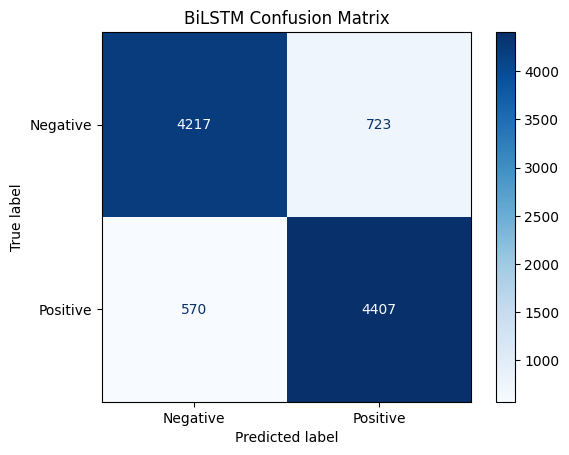

<Figure size 800x600 with 0 Axes>

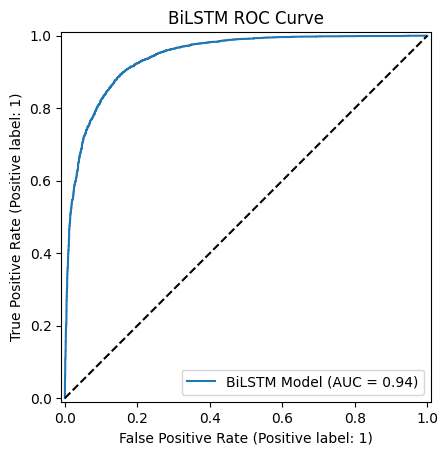

--- BiLSTM Model Evaluation Complete ---

--- CNN + LSTM Hybrid Model Architecture ---
CNN + LSTM Model Summary:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

--- CNN + LSTM Model Training ---
Epoch 1/20
1116/1116 ━━━━━━━━━━━━━━━━━━━━ 196s 172ms/step - accuracy: 0.7790 - loss: 0.4582 - val_accuracy: 0.8508 - val_loss: 0.3476 - learning_rate: 0.0010
Epoch 2/20
1116/1116 ━━━━━━━━━━━━━━━━━━━━ 197s 176ms/step - accuracy: 0.9009 - loss: 0.2660 - val_accuracy: 0.8692 - val_loss: 0.3139 - learning_rate: 0.0010
Epoch 3/20
1116/1116 ━━━━━━━━━━━━━━━━━━━━ 191s 171ms/step - accuracy: 0.9354 - loss: 0.1877 - val_accuracy: 0.8722 - val_loss: 0.3437 - learning_rate: 0.0010
Epoch 4/20
1116/1116 ━━━━━━━━━━━━━━━━━━━━ 189s 169ms/step - accuracy: 0.9625 - loss: 0.1171 - val_accuracy: 0.8661 - val_loss: 0.4355 - learning_rate: 0.0010
Epoch 5/20
1116/1116 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - accuracy: 0.9821 - loss: 0.0676
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
1116/1116 ━━━━━━━━━━━━━━━━━━━━ 203s 170ms/step - accuracy: 0.9786 - loss: 0.0745 - val_accuracy: 0.8583 - val_loss: 0.4344 - learning_rate: 0.0010
Epoch 6/20
1116/1116 

<Figure size 800x600 with 0 Axes>

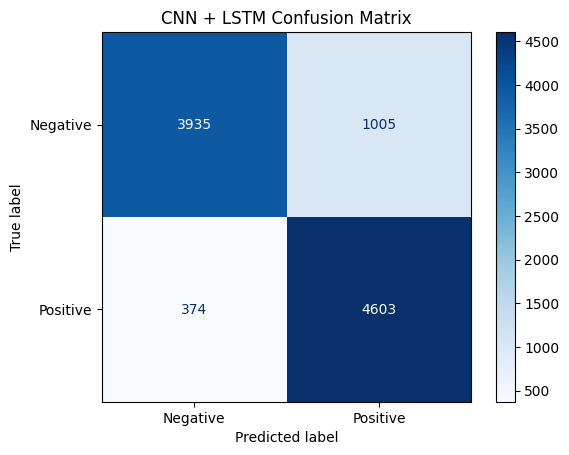

<Figure size 800x600 with 0 Axes>

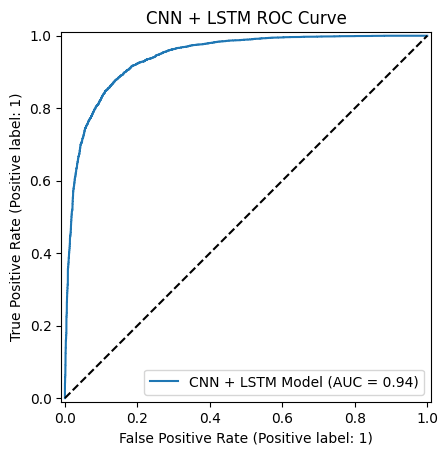

--- CNN + LSTM Model Evaluation Complete ---

--- BERT Model (Conceptual Setup) ---
Implementing a full BERT model for text classification involves several steps, including:
1. Installing the `transformers` library: `!pip install transformers`
2. Loading a pre-trained BERT tokenizer (e.g., `BertTokenizerFast.from_pretrained('bert-base-uncased')`).
3. Tokenizing the text data using the BERT tokenizer, which includes special tokens (CLS, SEP), attention masks, and token type IDs.
4. Loading a pre-trained BERT model for sequence classification (e.g., `TFBertForSequenceClassification.from_pretrained('bert-base-uncased')`).
5. Fine-tuning the BERT model on your specific dataset. This is often computationally intensive and may require a GPU.
6. Evaluating the fine-tuned BERT model.

Here's a conceptual code snippet to illustrate loading a BERT model for sequence classification, but running the full fine-tuning process is beyond the scope of a single immediate execution due to time and resour

/tmp/ipykernel_5506/776412745.py:193: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Accuracy', data=comparison_df_all, palette='viridis')
/tmp/ipykernel_5506/776412745.py:199: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='F1-score', data=comparison_df_all, palette='viridis')


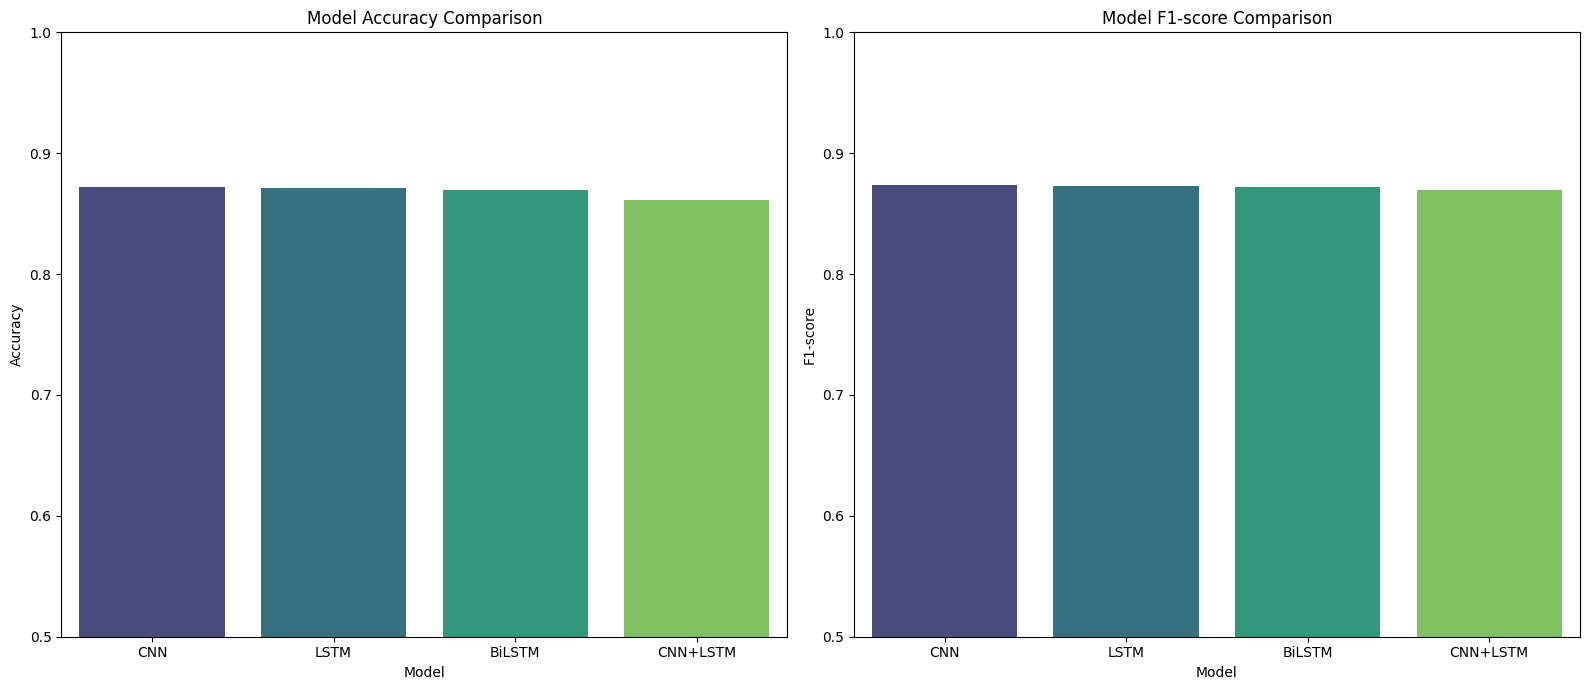

--- Overall Model Comparison Complete ---


In [ ]:
# Re-using parameters from previous steps
# VOCAB_SIZE, EMBEDDING_DIM, MAX_SEQUENCE_LENGTH, X_train, X_test, y_train, y_test

print("--- BiLSTM Model Architecture ---")

# Build the BiLSTM Model
model_bilstm = Sequential([
    Embedding(input_dim=VOCAB_SIZE + 1, output_dim=EMBEDDING_DIM, input_length=MAX_SEQUENCE_LENGTH),
    Bidirectional(LSTM(128, return_sequences=False)), # return_sequences=False for classification
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

# Compile the model
model_bilstm.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("BiLSTM Model Summary:")
model_bilstm.summary()

print("--- BiLSTM Model Training ---")

# Define Callbacks for BiLSTM
early_stopping_bilstm = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr_bilstm = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=0.00001, verbose=1)

# Train the BiLSTM model
history_bilstm = model_bilstm.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stopping_bilstm, reduce_lr_bilstm]
)

print("--- BiLSTM Model Training Complete ---")

print("--- BiLSTM Model Evaluation ---")

y_pred_prob_bilstm = model_bilstm.predict(X_test)
y_pred_bilstm = (y_pred_prob_bilstm > 0.5).astype(int)

accuracy_bilstm = accuracy_score(y_test, y_pred_bilstm)
precision_bilstm = precision_score(y_test, y_pred_bilstm)
recall_bilstm = recall_score(y_test, y_pred_bilstm)
f1_bilstm = f1_score(y_test, y_pred_bilstm)
roc_auc_bilstm = roc_auc_score(y_test, y_pred_prob_bilstm)

print(f"\nBiLSTM Accuracy: {accuracy_bilstm:.4f}")
print(f"BiLSTM Precision: {precision_bilstm:.4f}")
print(f"BiLSTM Recall: {recall_bilstm:.4f}")
print(f"BiLSTM F1-score: {f1_bilstm:.4f}")
print(f"BiLSTM ROC-AUC: {roc_auc_bilstm:.4f}")

plt.figure(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_bilstm, display_labels=['Negative', 'Positive'], cmap=plt.cm.Blues)
plt.title('BiLSTM Confusion Matrix')
plt.show()

plt.figure(figsize=(8, 6))
RocCurveDisplay.from_predictions(y_test, y_pred_prob_bilstm, name='BiLSTM Model')
plt.plot([0, 1], [0, 1], 'k--')
plt.title('BiLSTM ROC Curve')
plt.show()

print("--- BiLSTM Model Evaluation Complete ---")

print("\n--- CNN + LSTM Hybrid Model Architecture ---")

# Build the CNN + LSTM Hybrid Model
model_cnn_lstm = Sequential([
    Embedding(input_dim=VOCAB_SIZE + 1, output_dim=EMBEDDING_DIM, input_length=MAX_SEQUENCE_LENGTH),
    Conv1D(filters=128, kernel_size=5, activation='relu'),
    MaxPooling1D(pool_size=2),
    LSTM(128),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

# Compile the model
model_cnn_lstm.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("CNN + LSTM Model Summary:")
model_cnn_lstm.summary()

print("--- CNN + LSTM Model Training ---")

# Define Callbacks for CNN + LSTM
early_stopping_cnn_lstm = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr_cnn_lstm = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=0.00001, verbose=1)

# Train the CNN + LSTM model
history_cnn_lstm = model_cnn_lstm.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stopping_cnn_lstm, reduce_lr_cnn_lstm]
)

print("--- CNN + LSTM Model Training Complete ---")

print("--- CNN + LSTM Model Evaluation ---")

y_pred_prob_cnn_lstm = model_cnn_lstm.predict(X_test)
y_pred_cnn_lstm = (y_pred_prob_cnn_lstm > 0.5).astype(int)

accuracy_cnn_lstm = accuracy_score(y_test, y_pred_cnn_lstm)
precision_cnn_lstm = precision_score(y_test, y_pred_cnn_lstm)
recall_cnn_lstm = recall_score(y_test, y_pred_cnn_lstm)
f1_cnn_lstm = f1_score(y_test, y_pred_cnn_lstm)
roc_auc_cnn_lstm = roc_auc_score(y_test, y_pred_prob_cnn_lstm)

print(f"\nCNN + LSTM Accuracy: {accuracy_cnn_lstm:.4f}")
print(f"CNN + LSTM Precision: {precision_cnn_lstm:.4f}")
print(f"CNN + LSTM Recall: {recall_cnn_lstm:.4f}")
print(f"CNN + LSTM F1-score: {f1_cnn_lstm:.4f}")
print(f"CNN + LSTM ROC-AUC: {roc_auc_cnn_lstm:.4f}")

plt.figure(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_cnn_lstm, display_labels=['Negative', 'Positive'], cmap=plt.cm.Blues)
plt.title('CNN + LSTM Confusion Matrix')
plt.show()

plt.figure(figsize=(8, 6))
RocCurveDisplay.from_predictions(y_test, y_pred_prob_cnn_lstm, name='CNN + LSTM Model')
plt.plot([0, 1], [0, 1], 'k--')
plt.title('CNN + LSTM ROC Curve')
plt.show()

print("--- CNN + LSTM Model Evaluation Complete ---")


print("\n--- BERT Model (Conceptual Setup) ---")
print("Implementing a full BERT model for text classification involves several steps, including:")
print("1. Installing the `transformers` library: `!pip install transformers`")
print("2. Loading a pre-trained BERT tokenizer (e.g., `BertTokenizerFast.from_pretrained('bert-base-uncased')`).")
print("3. Tokenizing the text data using the BERT tokenizer, which includes special tokens (CLS, SEP), attention masks, and token type IDs.")
print("4. Loading a pre-trained BERT model for sequence classification (e.g., `TFBertForSequenceClassification.from_pretrained('bert-base-uncased')`).")
print("5. Fine-tuning the BERT model on your specific dataset. This is often computationally intensive and may require a GPU.")
print("6. Evaluating the fine-tuned BERT model.")
print("\nHere's a conceptual code snippet to illustrate loading a BERT model for sequence classification, but running the full fine-tuning process is beyond the scope of a single immediate execution due to time and resource constraints:")

print("\n```python")
bert_conceptual_code = """
# Example: Loading BERT tokenizer and model (requires transformers library)
# from transformers import AutoTokenizer, TFAutoModelForSequenceClassification

# # Load pre-trained tokenizer
# tokenizer_bert = AutoTokenizer.from_pretrained('bert-base-uncased')

# # Load pre-trained BERT model for sequence classification
# model_bert = TFAutoModelForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2)

# # You would then tokenize your X_train, X_test with `tokenizer_bert.batch_encode_plus`,
# # create tensorflow datasets, and fine-tune `model_bert`.
# # This process is significantly more involved than the CNN/LSTM models.
"""
print(bert_conceptual_code)
print("```")
print("--- BERT Model (Conceptual Setup) Complete ---")


print("\n--- Overall Model Comparison ---")

# Gather metrics for comparison
metrics_data = {
    'Model': ['CNN', 'LSTM', 'BiLSTM', 'CNN+LSTM'],
    'Accuracy': [accuracy, accuracy_lstm, accuracy_bilstm, accuracy_cnn_lstm],
    'Precision': [precision, precision_lstm, precision_bilstm, precision_cnn_lstm],
    'Recall': [recall, recall_lstm, recall_bilstm, recall_cnn_lstm],
    'F1-score': [f1, f1_lstm, f1_bilstm, f1_cnn_lstm],
    'ROC-AUC': [roc_auc, roc_auc_lstm, roc_auc_bilstm, roc_auc_cnn_lstm],
    'Training Epochs': [len(history_dict['accuracy']), len(history_dict_lstm['accuracy']),
                        len(history_bilstm.history['accuracy']), len(history_cnn_lstm.history['accuracy'])]
}

# Create DataFrame for comparison table
comparison_df_all = pd.DataFrame(metrics_data)
print("\nUpdated Model Comparison Table:")
print(comparison_df_all.round(4).to_markdown(index=False))

# Visualization Charts for Comparison
plt.figure(figsize=(16, 7))

# Bar chart for Accuracy
plt.subplot(1, 2, 1)
sns.barplot(x='Model', y='Accuracy', data=comparison_df_all, palette='viridis')
plt.title('Model Accuracy Comparison')
plt.ylim(0.5, 1.0) # Set y-limit for better comparison

# Bar chart for F1-score
plt.subplot(1, 2, 2)
sns.barplot(x='Model', y='F1-score', data=comparison_df_all, palette='viridis')
plt.title('Model F1-score Comparison')
plt.ylim(0.5, 1.0)

plt.tight_layout()
plt.show()

print("--- Overall Model Comparison Complete ---")


## Hyperparameter Tuning

In [23]:
print("--- Starting Accelerated Hyperparameter Tuning ---")

class MyHyperModel(kt.HyperModel):
    def build(self, hp):
        # Broad architecture choices take the longest. Keep step sizes large to limit internal parameter combinations.
        model_type = hp.Choice('model_type', ['cnn', 'lstm', 'bilstm', 'cnn_lstm'])

        # Keep step sizes large (64) to drastically cut down total combinations
        embedding_dim = hp.Int('embedding_dim', min_value=64, max_value=256, step=64)

        model = Sequential()
        model.add(Embedding(input_dim=VOCAB_SIZE + 1, output_dim=embedding_dim, input_length=MAX_SEQUENCE_LENGTH))

        if model_type == 'cnn':
            filters = hp.Int('filters', min_value=64, max_value=256, step=64)
            kernel_size = hp.Choice('kernel_size', values=[3, 5]) # Dropped 7 to save search iterations
            model.add(Conv1D(filters=filters, kernel_size=kernel_size, activation='relu'))
            model.add(MaxPooling1D(pool_size=2))
            model.add(Flatten())

        elif model_type == 'lstm':
            lstm_units = hp.Int('lstm_units', min_value=64, max_value=128, step=64)
            model.add(LSTM(lstm_units))

        elif model_type == 'bilstm':
            lstm_units = hp.Int('bilstm_units', min_value=64, max_value=128, step=64)
            model.add(Bidirectional(LSTM(lstm_units)))

        elif model_type == 'cnn_lstm':
            filters = hp.Int('filters_cnn_lstm', min_value=64, max_value=128, step=64)
            kernel_size = hp.Choice('kernel_size_cnn_lstm', values=[3, 5])
            lstm_units = hp.Int('lstm_units_cnn_lstm', min_value=64, max_value=128, step=64)

            model.add(Conv1D(filters=filters, kernel_size=kernel_size, activation='relu'))
            model.add(MaxPooling1D(pool_size=2))
            model.add(LSTM(lstm_units))

        # Common dense layers
        model.add(Dropout(hp.Float('dropout_1', min_value=0.2, max_value=0.4, step=0.2)))
        model.add(Dense(hp.Int('dense_units', min_value=32, max_value=96, step=32), activation='relu'))
        model.add(Dropout(hp.Float('dropout_2', min_value=0.2, max_value=0.4, step=0.2)))
        model.add(Dense(1, activation='sigmoid'))

        # Only search the two most standard effective learning rates for text data
        hp_learning_rate = hp.Choice('learning_rate', values=[1e-3, 1e-4])
        optimizer = Adam(learning_rate=hp_learning_rate)

        model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
        return model

    def fit(self, hp, model, *args, **kwargs):
        # CRITICAL SPEED UP: Larger batch sizes utilize GPU hardware much more efficiently.
        batch_size = hp.Choice('batch_size', values=[64, 128, 256])
        return model.fit(*args, batch_size=batch_size, **kwargs)

# Instantiate the custom HyperModel
hypermodel = MyHyperModel()

# Setup the tuner optimized for rapid pruning
tuner = kt.Hyperband(
    hypermodel,
    objective='val_accuracy',
    max_epochs=6,      # Reduced from 10. Hyperband aggressively drops bad models in early epochs.
    factor=3,
    directory='my_dir',
    project_name='fast_sentiment_tuning',
    overwrite=True
)

# CRITICAL SPEED UP: Aggressive early stopping ensures dead-end weights don't keep training.
early_stopping_tuner = EarlyStopping(monitor='val_loss', patience=1, restore_best_weights=True)
reduce_lr_tuner = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=1, min_lr=0.00001, verbose=0)

print("\nStarting Fast Hyperparameter Search...")

# Run the hyperparameter search
tuner.search(
    X_train,
    y_train,
    epochs=6,
    validation_split=0.1,
    callbacks=[early_stopping_tuner, reduce_lr_tuner],
    verbose=1
)

print("\nHyperparameter Search Complete.")

# --- Evaluation and Visualizations remain identical ---
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
best_model = tuner.get_best_models(num_models=1)[0]

print("\n--- Best Hyperparameters Found ---")
print(f"Best Model Type: {best_hps.get('model_type')}")
print(f"Best Embedding Dimension: {best_hps.get('embedding_dim')}")
print(f"Best Learning Rate: {best_hps.get('learning_rate')}")
print(f"Best Batch Size: {best_hps.get('batch_size')}")

loss, accuracy = best_model.evaluate(X_test, y_test, verbose=0)
y_pred_prob_best = best_model.predict(X_test)
y_pred_best = (y_pred_prob_best > 0.5).astype(int)

accuracy_best = accuracy_score(y_test, y_pred_best)
precision_best = precision_score(y_test, y_pred_best)
recall_best = recall_score(y_test, y_pred_best)
f1_best = f1_score(y_test, y_pred_best)
roc_auc_best = roc_auc_score(y_test, y_pred_prob_best)

try:
    metrics_data_recreate = {
        'Model': ['CNN', 'LSTM', 'BiLSTM', 'CNN+LSTM'],
        'Accuracy': [accuracy, accuracy_lstm, accuracy_bilstm, accuracy_cnn_lstm],
        'Precision': [precision, precision_lstm, precision_bilstm, precision_cnn_lstm],
        'Recall': [recall, recall_lstm, recall_bilstm, recall_cnn_lstm],
        'F1-score': [f1, f1_lstm, f1_bilstm, f1_cnn_lstm],
        'ROC-AUC': [roc_auc, roc_auc_lstm, roc_auc_bilstm, roc_auc_cnn_lstm],
        'Training Epochs': [len(history_dict['accuracy']), len(history_dict_lstm['accuracy']),
                            len(history_bilstm.history['accuracy']), len(history_cnn_lstm.history['accuracy'])]
    }
    comparison_df_all_base = pd.DataFrame(metrics_data_recreate)
except NameError:
    comparison_df_all_base = pd.DataFrame(columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1-score', 'ROC-AUC', 'Training Epochs'])

best_model_metrics = {
    'Model': ['Best Tuned Model'],
    'Accuracy': [accuracy_best],
    'Precision': [precision_best],
    'Recall': [recall_best],
    'F1-score': [f1_best],
    'ROC-AUC': [roc_auc_best],
    'Training Epochs': [len(best_model.history.history['accuracy'])] if hasattr(best_model, 'history') and 'accuracy' in best_model.history.history else ['N/A']
}
best_model_df = pd.DataFrame(best_model_metrics)
comparison_df_all_updated = pd.concat([comparison_df_all_base, best_model_df], ignore_index=True)

print("\nUpdated Model Comparison Table (including Tuned Model):")
print(comparison_df_all_updated.round(4).to_markdown(index=False))

Trial 10 Complete [00h 08m 02s]
val_accuracy: 0.872447669506073

Best val_accuracy So Far: 0.8837912678718567
Total elapsed time: 00h 53m 33s

Hyperparameter Search Complete.

--- Best Hyperparameters Found ---
Best Model Type: cnn
Best Embedding Dimension: 64
Best Learning Rate: 0.0001
Best Batch Size: 128
310/310 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step

Updated Model Comparison Table (including Tuned Model):
| Model            |   Accuracy |   Precision |   Recall |   F1-score |   ROC-AUC | Training Epochs   |
|:-----------------|-----------:|------------:|---------:|-----------:|----------:|:------------------|
| CNN              |     0.8718 |      0.8684 |   0.879  |     0.8737 |    0.9466 | 7                 |
| LSTM             |     0.8711 |      0.8646 |   0.8813 |     0.8728 |    0.9443 | 9                 |
| BiLSTM           |     0.8696 |      0.8591 |   0.8855 |     0.8721 |    0.943  | 7                 |
| CNN+LSTM         |     0.8609 |      0.8208 |   0.9249 |     0.8697 |  

## Model Evaluation and Confusion Matrices


--- Detailed Model Evaluation and Confusion Matrices ---

--- Evaluating CNN Model ---
Accuracy: 0.8724
Precision: 0.8684
Recall: 0.8790
F1-score: 0.8737
ROC-AUC: 0.9466


<Figure size 600x500 with 0 Axes>

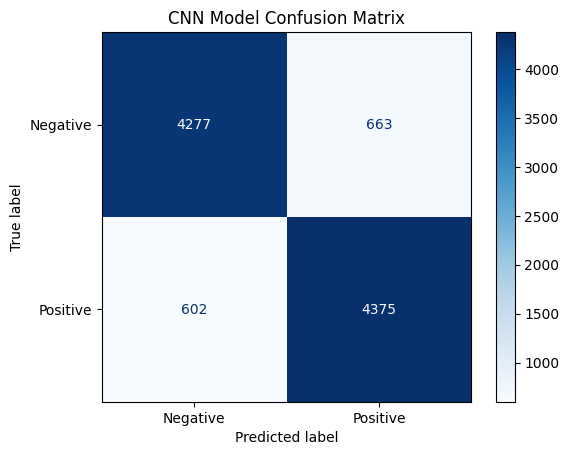

<Figure size 600x500 with 0 Axes>

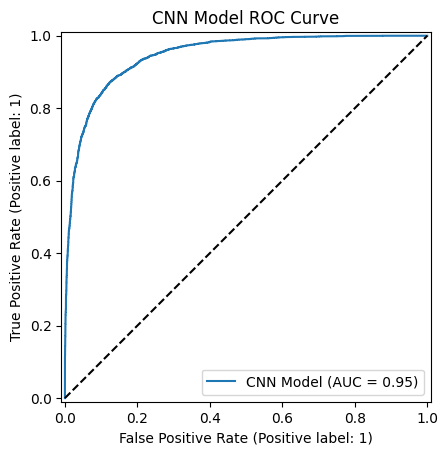


--- Evaluating LSTM Model ---
Accuracy: 0.8711
Precision: 0.8646
Recall: 0.8813
F1-score: 0.8728
ROC-AUC: 0.9443


<Figure size 600x500 with 0 Axes>

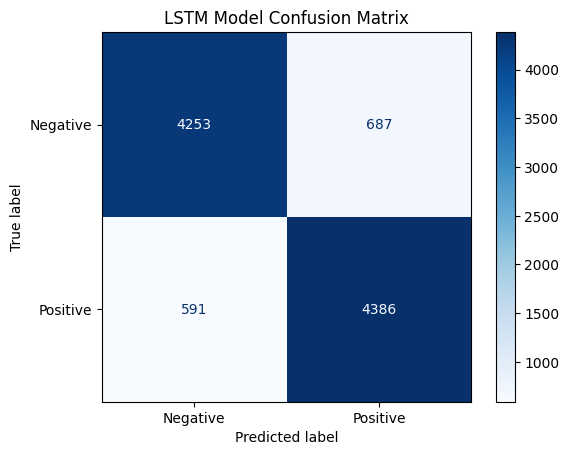

<Figure size 600x500 with 0 Axes>

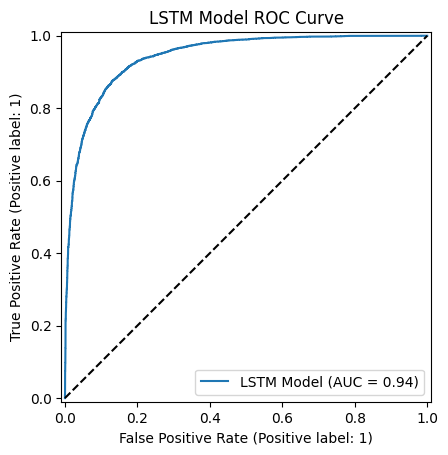


--- Evaluating BiLSTM Model ---
Accuracy: 0.8696
Precision: 0.8591
Recall: 0.8855
F1-score: 0.8721
ROC-AUC: 0.9430


<Figure size 600x500 with 0 Axes>

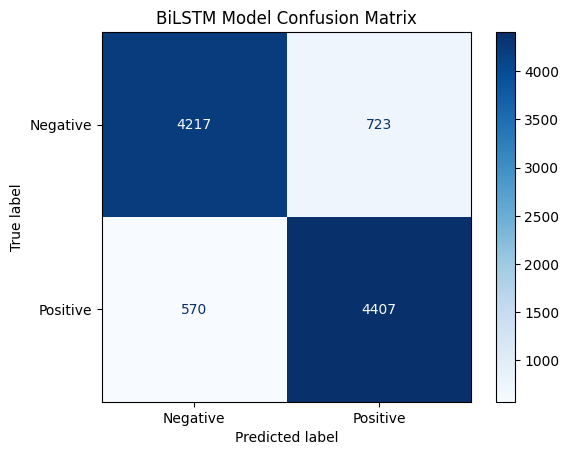

<Figure size 600x500 with 0 Axes>

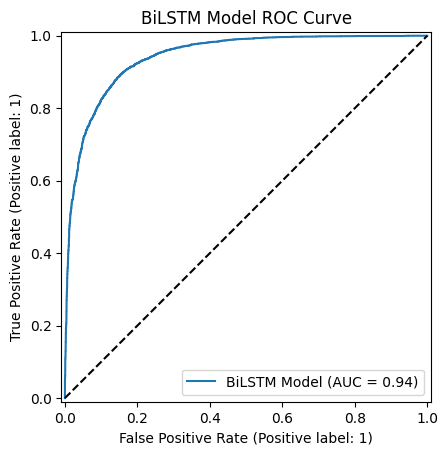


--- Evaluating CNN+LSTM Model ---
Accuracy: 0.8609
Precision: 0.8208
Recall: 0.9249
F1-score: 0.8697
ROC-AUC: 0.9423


<Figure size 600x500 with 0 Axes>

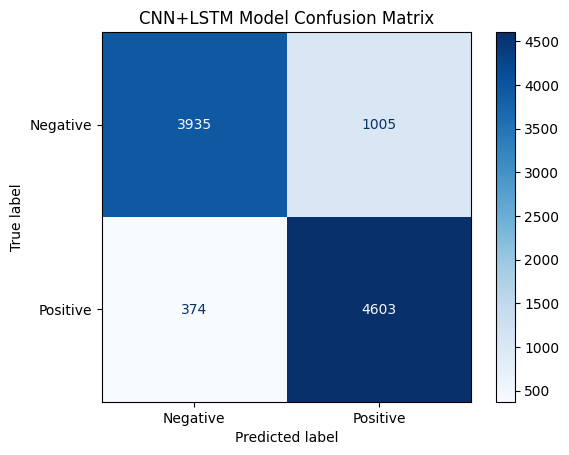

<Figure size 600x500 with 0 Axes>

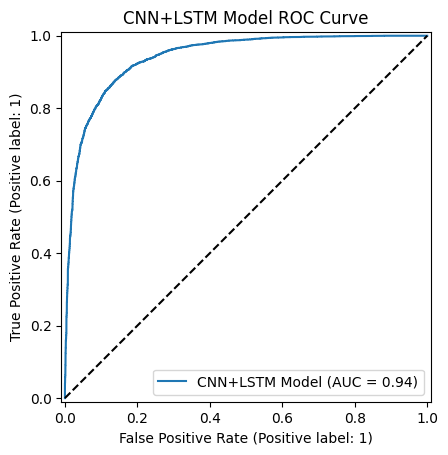


--- Evaluating Best Tuned Model ---
Accuracy: 0.8718
Precision: 0.8609
Recall: 0.8881
F1-score: 0.8743
ROC-AUC: 0.9462


<Figure size 600x500 with 0 Axes>

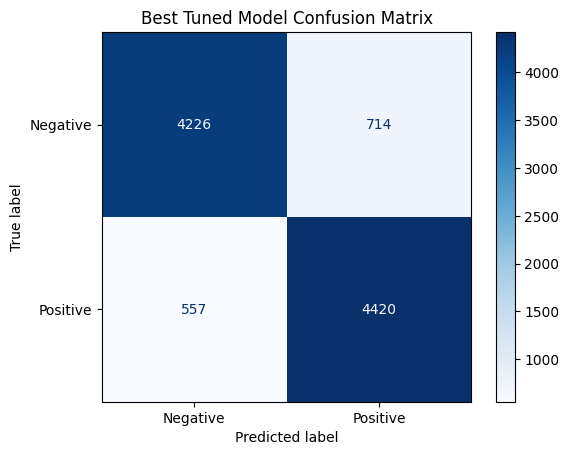

<Figure size 600x500 with 0 Axes>

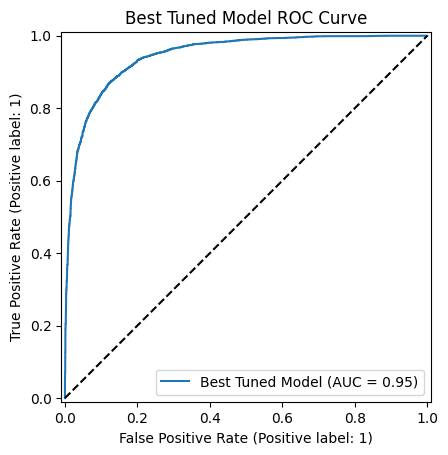


--- Detailed Model Evaluation Complete ---

--- Updated Model Comparison Table (including Tuned Model):---
| Model            |   Accuracy |   Precision |   Recall |   F1-score |   ROC-AUC | Training Epochs   |
|:-----------------|-----------:|------------:|---------:|-----------:|----------:|:------------------|
| CNN              |     0.8718 |      0.8684 |   0.879  |     0.8737 |    0.9466 | 7                 |
| LSTM             |     0.8711 |      0.8646 |   0.8813 |     0.8728 |    0.9443 | 9                 |
| BiLSTM           |     0.8696 |      0.8591 |   0.8855 |     0.8721 |    0.943  | 7                 |
| CNN+LSTM         |     0.8609 |      0.8208 |   0.9249 |     0.8697 |    0.9423 | 7                 |
| Best Tuned Model |     0.8718 |      0.8609 |   0.8881 |     0.8743 |    0.9462 | N/A               |


/tmp/ipykernel_5506/504200270.py:76: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Accuracy', data=comparison_df_all_updated, palette='viridis')
/tmp/ipykernel_5506/504200270.py:82: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='F1-score', data=comparison_df_all_updated, palette='viridis')


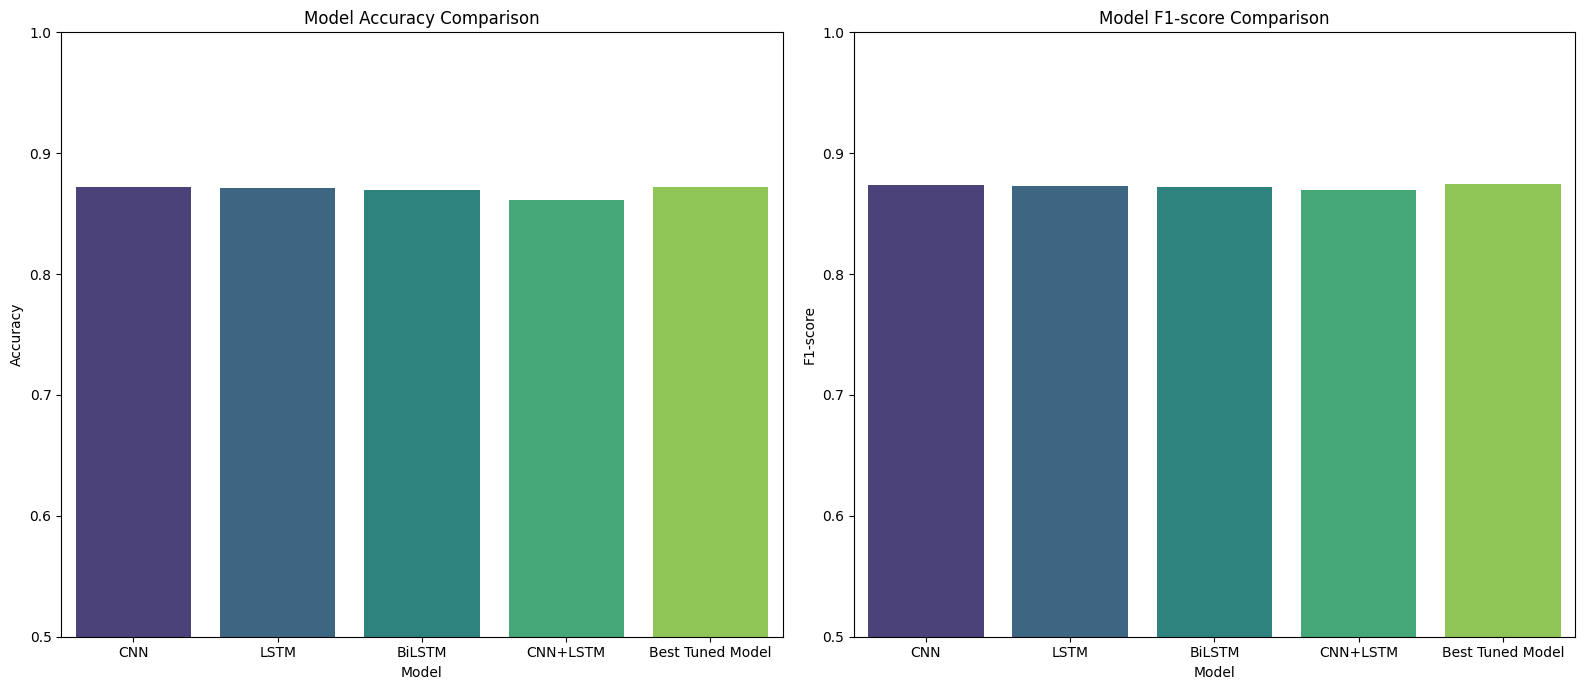

In [24]:
print("\n--- Detailed Model Evaluation and Confusion Matrices ---")

# Assuming y_test, X_test, and the models/predictions (y_pred_prob, y_pred, etc.) are in the kernel state

models_and_predictions = {
    'CNN Model': {
        'model_name': 'CNN Model',
        'y_pred_prob': y_pred_prob, # From previous CNN evaluation
        'y_pred': y_pred # From previous CNN evaluation
    },
    'LSTM Model': {
        'model_name': 'LSTM Model',
        'y_pred_prob': y_pred_prob_lstm, # From previous LSTM evaluation
        'y_pred': y_pred_lstm # From previous LSTM evaluation
    },
    'BiLSTM Model': {
        'model_name': 'BiLSTM Model',
        'y_pred_prob': y_pred_prob_bilstm, # From previous BiLSTM evaluation
        'y_pred': y_pred_bilstm # From previous BiLSTM evaluation
    },
    'CNN+LSTM Model': {
        'model_name': 'CNN+LSTM Model',
        'y_pred_prob': y_pred_prob_cnn_lstm, # From previous CNN+LSTM evaluation
        'y_pred': y_pred_cnn_lstm # From previous CNN+LSTM evaluation
    },
    'Best Tuned Model': {
        'model_name': 'Best Tuned Model',
        'y_pred_prob': y_pred_prob_best, # From Keras Tuner best model evaluation
        'y_pred': y_pred_best # From Keras Tuner best model evaluation
    }
}

for model_key, data in models_and_predictions.items():
    print(f"\n--- Evaluating {data['model_name']} ---")

    # Calculate metrics
    accuracy = accuracy_score(y_test, data['y_pred'])
    precision = precision_score(y_test, data['y_pred'])
    recall = recall_score(y_test, data['y_pred'])
    f1 = f1_score(y_test, data['y_pred'])
    roc_auc = roc_auc_score(y_test, data['y_pred_prob'])

    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-score: {f1:.4f}")
    print(f"ROC-AUC: {roc_auc:.4f}")

    # Plot Confusion Matrix
    cm = confusion_matrix(y_test, data['y_pred'])
    plt.figure(figsize=(6, 5))
    cmd = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negative', 'Positive'])
    cmd.plot(cmap=plt.cm.Blues)
    plt.title(f'{data["model_name"]} Confusion Matrix')
    plt.show()

    # Plot ROC Curve
    plt.figure(figsize=(6, 5))
    RocCurveDisplay.from_predictions(y_test, data['y_pred_prob'], name=data['model_name'])
    plt.plot([0, 1], [0, 1], 'k--')
    plt.title(f'{data["model_name"]} ROC Curve')
    plt.show()

print("\n--- Detailed Model Evaluation Complete ---")

print("\n--- Updated Model Comparison Table (including Tuned Model):---")
# Ensure 'comparison_df_all_updated' is available
if 'comparison_df_all_updated' in globals():
    print(comparison_df_all_updated.round(4).to_markdown(index=False))

    # Visualization Charts for Comparison (re-plotting for clarity)
    plt.figure(figsize=(16, 7))

    # Bar chart for Accuracy
    plt.subplot(1, 2, 1)
    sns.barplot(x='Model', y='Accuracy', data=comparison_df_all_updated, palette='viridis')
    plt.title('Model Accuracy Comparison')
    plt.ylim(0.5, 1.0) # Set y-limit for better comparison

    # Bar chart for F1-score
    plt.subplot(1, 2, 2)
    sns.barplot(x='Model', y='F1-score', data=comparison_df_all_updated, palette='viridis')
    plt.title('Model F1-score Comparison')
    plt.ylim(0.5, 1.0)

    plt.tight_layout()
    plt.show()
else:
    print("Error: 'comparison_df_all_updated' not found. Cannot display comparison table and charts.")



In [25]:
print("--- Making Predictions with Best Tuned Model and Comparing to Actuals ---")

# Assuming best_model, X_test, and y_test are available from previous steps

# Make predictions (probabilities)
y_pred_prob_final = best_model.predict(X_test)

# Convert probabilities to binary predictions (0 or 1) using a threshold of 0.5
y_pred_final = (y_pred_prob_final > 0.5).astype(int)

print("\nSample of Actual vs. Predicted values:")
print("--------------------------------------")

# Display a few samples (e.g., first 10)
num_samples = 10
for i in range(num_samples):
    actual = y_test[i]
    predicted = y_pred_final[i][0] # Access the scalar value from the array
    probability = y_pred_prob_final[i][0]
    print(f"Sample {i+1}: Actual = {actual}, Predicted = {predicted}, Probability = {probability:.4f}")

print("--------------------------------------")

# You can also use metrics from the overall evaluation that was already run
# For example:
print(f"\nOverall Accuracy of Best Tuned Model on Test Set: {accuracy_best:.4f}")
print(f"Overall Precision of Best Tuned Model on Test Set: {precision_best:.4f}")
print(f"Overall Recall of Best Tuned Model on Test Set: {recall_best:.4f}")
print(f"Overall F1-score of Best Tuned Model on Test Set: {f1_best:.4f}")
print(f"Overall ROC-AUC of Best Tuned Model on Test Set: {roc_auc_best:.4f}")

print("\n--- Prediction and Comparison Complete ---")

--- Making Predictions with Best Tuned Model and Comparing to Actuals ---
310/310 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step

Sample of Actual vs. Predicted values:
--------------------------------------
Sample 1: Actual = 0, Predicted = 0, Probability = 0.0075
Sample 2: Actual = 1, Predicted = 1, Probability = 0.9843
Sample 3: Actual = 1, Predicted = 1, Probability = 0.9278
Sample 4: Actual = 0, Predicted = 0, Probability = 0.2400
Sample 5: Actual = 0, Predicted = 0, Probability = 0.0716
Sample 6: Actual = 1, Predicted = 1, Probability = 0.9519
Sample 7: Actual = 0, Predicted = 0, Probability = 0.0296
Sample 8: Actual = 0, Predicted = 1, Probability = 0.5529
Sample 9: Actual = 1, Predicted = 1, Probability = 0.9678
Sample 10: Actual = 0, Predicted = 0, Probability = 0.0067
--------------------------------------

Overall Accuracy of Best Tuned Model on Test Set: 0.8718
Overall Precision of Best Tuned Model on Test Set: 0.8609
Overall Recall of Best Tuned Model on Test Set: 0.8881
Overall F1-scor

In [27]:
print("--- Saving important files for deployment ---")

# 1. Save the best_model
model_save_path = 'best_tuned_sentiment_model.keras'
best_model.save(model_save_path)
print(f"Best tuned model saved to: {model_save_path}")

# 2. Save the tokenizer
tokenizer_save_path = 'tokenizer.pickle'
with open(tokenizer_save_path, 'wb') as handle:
    pickle.dump(tokenizer, handle, protocol=pickle.HIGHEST_PROTOCOL)
print(f"Tokenizer saved to: {tokenizer_save_path}")

# 3. Save MAX_SEQUENCE_LENGTH and VOCAB_SIZE
# These are crucial for preprocessing new text data before feeding it to the model
nlp_params = {
    'MAX_SEQUENCE_LENGTH': MAX_SEQUENCE_LENGTH,
    'VOCAB_SIZE': VOCAB_SIZE
}
nlp_params_save_path = 'nlp_parameters.json'
with open(nlp_params_save_path, 'w') as fp:
    json.dump(nlp_params, fp)
print(f"NLP parameters (MAX_SEQUENCE_LENGTH, VOCAB_SIZE) saved to: {nlp_params_save_path}")

print("--- All deployment artifacts saved successfully ---")

--- Saving important files for deployment ---
Best tuned model saved to: best_tuned_sentiment_model.keras
Tokenizer saved to: tokenizer.pickle
NLP parameters (MAX_SEQUENCE_LENGTH, VOCAB_SIZE) saved to: nlp_parameters.json
--- All deployment artifacts saved successfully ---
